In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [40]:
file_path = "Data_file.xlsx"
sheet_name = "HTL"

df = pd.read_excel('Data_file.xlsx', sheet_name='HTL')

print("Original Columns:")
print(df.columns.tolist())

Original Columns:
['Jsc', 'v(V)', 't=100[nm]', 't=200[nm]', 't=300[nm]', 't=400[nm]', 't=500[nm]', 't=600[nm]', 't=700[nm]', 't=800[nm]', 't=900[nm]', 't=1000[nm]', 'Unnamed: 12', 'Unnamed: 13', 'thickness(nm)', 'Jsc(mA/cm^2)', 'Unnamed: 16', 'Unnamed: 17', 'Q.E.(%)', 'lambda(nm)', 't=100[nm].1', 't=200[nm].1', 't=300[nm].1', 't=400[nm].1', 't=500[nm].1', 't=600[nm].1', 't=700[nm].1', 't=800[nm].1', 't=900[nm].1', 't=1000[nm].1', 'Unnamed: 30', 'Unnamed: 31', 'R(A/W)', 'lambda(nm).1', 't=100[nm].2', 't=200[nm].2', 't=300[nm].2', 't=400[nm].2', 't=500[nm].2', 't=600[nm].2', 't=700[nm].2', 't=800[nm].2', 't=900[nm].2', 't=1000[nm].2']


In [41]:
# Remove unnamed columns (Excel artifacts)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Strip spaces
df.columns = df.columns.str.strip()

print("Cleaned Columns:")
print(df.columns.tolist())

Cleaned Columns:
['Jsc', 'v(V)', 't=100[nm]', 't=200[nm]', 't=300[nm]', 't=400[nm]', 't=500[nm]', 't=600[nm]', 't=700[nm]', 't=800[nm]', 't=900[nm]', 't=1000[nm]', 'thickness(nm)', 'Jsc(mA/cm^2)', 'Q.E.(%)', 'lambda(nm)', 't=100[nm].1', 't=200[nm].1', 't=300[nm].1', 't=400[nm].1', 't=500[nm].1', 't=600[nm].1', 't=700[nm].1', 't=800[nm].1', 't=900[nm].1', 't=1000[nm].1', 'R(A/W)', 'lambda(nm).1', 't=100[nm].2', 't=200[nm].2', 't=300[nm].2', 't=400[nm].2', 't=500[nm].2', 't=600[nm].2', 't=700[nm].2', 't=800[nm].2', 't=900[nm].2', 't=1000[nm].2']


In [42]:
jv_cols = [col for col in df.columns if 't=' in col and '.1' not in col and '.2' not in col]
qe_cols = [col for col in df.columns if 't=' in col and '.1' in col]
r_cols  = [col for col in df.columns if 't=' in col and '.2' in col]

print("J-V Columns:", jv_cols[:5])
print("QE Columns:", qe_cols[:5])
print("R Columns:", r_cols[:5])

J-V Columns: ['t=100[nm]', 't=200[nm]', 't=300[nm]', 't=400[nm]', 't=500[nm]']
QE Columns: ['t=100[nm].1', 't=200[nm].1', 't=300[nm].1', 't=400[nm].1', 't=500[nm].1']
R Columns: ['t=100[nm].2', 't=200[nm].2', 't=300[nm].2', 't=400[nm].2', 't=500[nm].2']


In [43]:
jv_df = df[['v(V)'] + jv_cols].copy()

# Drop missing rows
jv_df = jv_df.dropna()

# Convert wide → long
jv_long = jv_df.melt(id_vars='v(V)', var_name='Parameter', value_name='Current')

# Extract numeric thickness
jv_long['Parameter'] = jv_long['Parameter'].str.extract(r'(\d+)')

# Convert to numeric safely
jv_long = jv_long.apply(pd.to_numeric, errors='coerce')

# Drop NaN after conversion
jv_long = jv_long.dropna()

# Remove duplicates
jv_long = jv_long.drop_duplicates()

# Rename
jv_long.rename(columns={'v(V)': 'Voltage'}, inplace=True)

# Sort
jv_long = jv_long.sort_values(['Parameter', 'Voltage'])

jv_long.head()

,Voltage,Parameter,Current
0,0.00,100,20.506650
1,0.05,100,20.506456
2,0.10,100,20.506259
3,0.15,100,20.506057
4,0.20,100,20.505850


In [44]:
qe_df = df[['lambda(nm)'] + qe_cols].copy()

qe_df = qe_df.dropna()

qe_long = qe_df.melt(id_vars='lambda(nm)', var_name='Parameter', value_name='QE')

qe_long['Parameter'] = qe_long['Parameter'].str.extract(r'(\d+)')

qe_long = qe_long.apply(pd.to_numeric, errors='coerce')

qe_long = qe_long.dropna()

qe_long = qe_long.drop_duplicates()

qe_long.rename(columns={'lambda(nm)': 'Wavelength'}, inplace=True)

qe_long = qe_long.sort_values(['Parameter', 'Wavelength'])

qe_long.head()

,Wavelength,Parameter,QE
0,300,100,84.92375
1,310,100,85.89259
2,320,100,86.88855
3,330,100,87.92427
4,340,100,89.01795


In [45]:
r_df = df[['lambda(nm).1'] + r_cols].copy()

r_df = r_df.dropna()

r_long = r_df.melt(id_vars='lambda(nm).1', var_name='Parameter', value_name='Responsivity')

r_long['Parameter'] = r_long['Parameter'].str.extract(r'(\d+)')

r_long = r_long.apply(pd.to_numeric, errors='coerce')

r_long = r_long.dropna()

r_long = r_long.drop_duplicates()

r_long.rename(columns={'lambda(nm).1': 'Wavelength'}, inplace=True)

r_long = r_long.sort_values(['Parameter', 'Wavelength'])

r_long.head()

,Wavelength,Parameter,Responsivity
0,300,100,0.205461
1,310,100,0.214731
2,320,100,0.224229
3,330,100,0.233992
4,340,100,0.244081


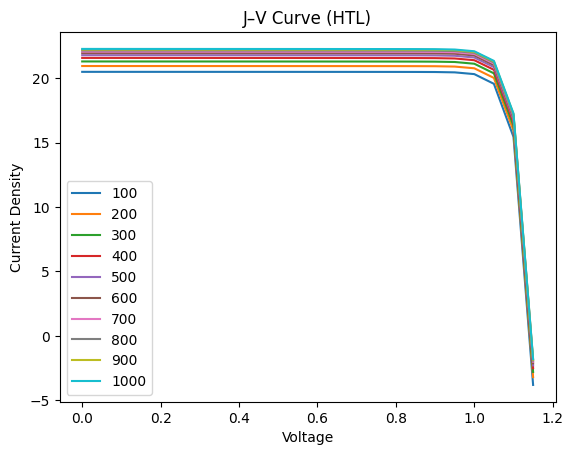

In [46]:
plt.figure()

for p in sorted(jv_long['Parameter'].unique()):
    subset = jv_long[jv_long['Parameter'] == p]
    plt.plot(subset['Voltage'], subset['Current'], label=f"{p}")

plt.xlabel("Voltage")
plt.ylabel("Current Density")
plt.title("J–V Curve (HTL)")
plt.legend()
plt.show()

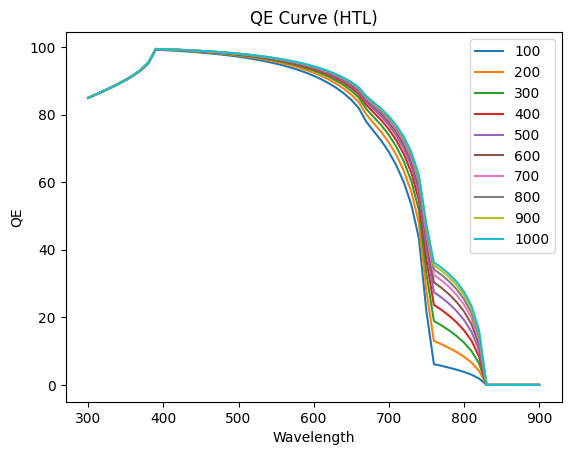

In [47]:
plt.figure()

for p in sorted(qe_long['Parameter'].unique()):
    subset = qe_long[qe_long['Parameter'] == p]
    plt.plot(subset['Wavelength'], subset['QE'], label=f"{p}")

plt.xlabel("Wavelength")
plt.ylabel("QE")
plt.title("QE Curve (HTL)")
plt.legend()
plt.show()

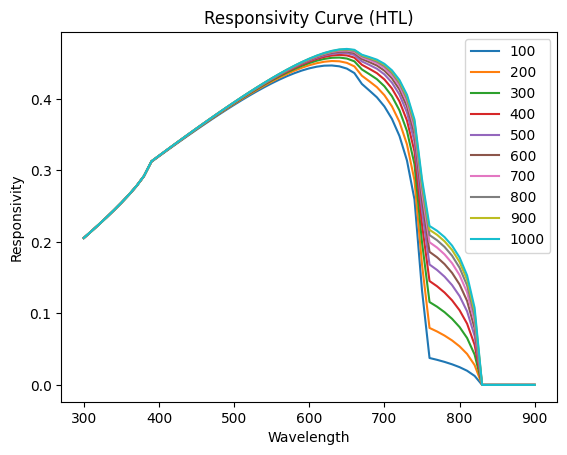

In [48]:
plt.figure()

for p in sorted(r_long['Parameter'].unique()):
    subset = r_long[r_long['Parameter'] == p]
    plt.plot(subset['Wavelength'], subset['Responsivity'], label=f"{p}")

plt.xlabel("Wavelength")
plt.ylabel("Responsivity")
plt.title("Responsivity Curve (HTL)")
plt.legend()
plt.show()

In [49]:
X_jv = jv_long[['Voltage', 'Parameter']]
y_jv = jv_long['Current']

X_train, X_test, y_train, y_test = train_test_split(X_jv, y_jv, test_size=0.2, random_state=42)

model_jv = RandomForestRegressor(n_estimators=100)
model_jv.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
X_qe = qe_long[['Wavelength', 'Parameter']]
y_qe = qe_long['QE']

X_train_qe, X_test_qe, y_train_qe, y_test_qe = train_test_split(X_qe, y_qe, test_size=0.2, random_state=42)

model_qe = RandomForestRegressor(n_estimators=100)
model_qe.fit(X_train_qe, y_train_qe)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [51]:
X_r = r_long[['Wavelength', 'Parameter']]
y_r = r_long['Responsivity']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, test_size=0.2, random_state=42)

model_r = RandomForestRegressor(n_estimators=100)
model_r.fit(X_train_r, y_train_r)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

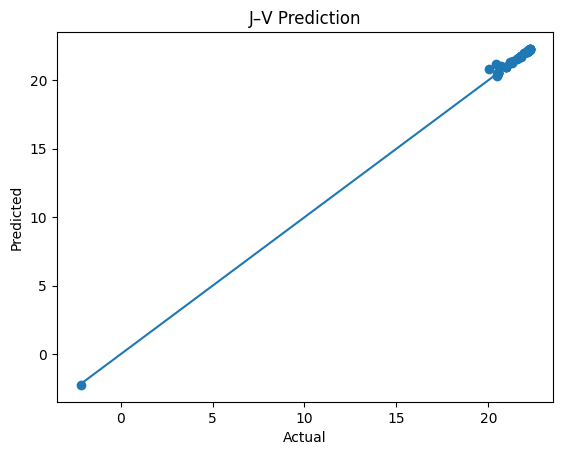

R2: 0.9974209720631259
MAE: 0.055619517883334794


In [52]:
y_pred = model_jv.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred)

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("J–V Prediction")
plt.show()

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

In [55]:
def predict_current(voltage, parameter):
    return model_jv.predict([[voltage, parameter]])[0]

def predict_qe(wavelength, parameter):
    return model_qe.predict([[wavelength, parameter]])[0]

def predict_responsivity(wavelength, parameter):
    return model_r.predict([[wavelength, parameter]])[0]

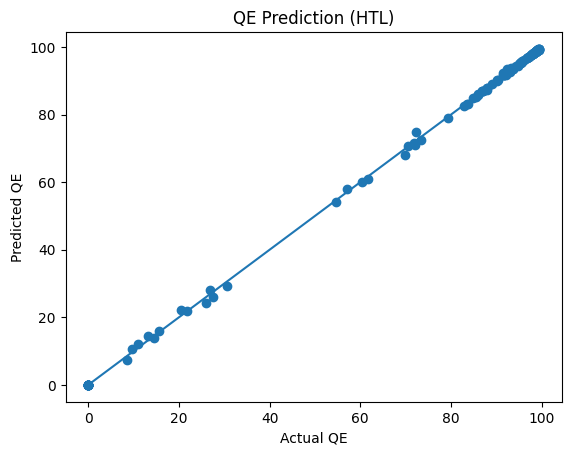

R2: 0.9998015479788013
MAE: 0.2605241011096714


In [56]:
# Predict
y_pred_qe = model_qe.predict(X_test_qe)

# Plot
plt.figure()
plt.scatter(y_test_qe, y_pred_qe)

# Ideal line
min_val = min(min(y_test_qe), min(y_pred_qe))
max_val = max(max(y_test_qe), max(y_pred_qe))

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual QE")
plt.ylabel("Predicted QE")
plt.title("QE Prediction (HTL)")
plt.show()

# Metrics
print("R2:", r2_score(y_test_qe, y_pred_qe))
print("MAE:", mean_absolute_error(y_test_qe, y_pred_qe))

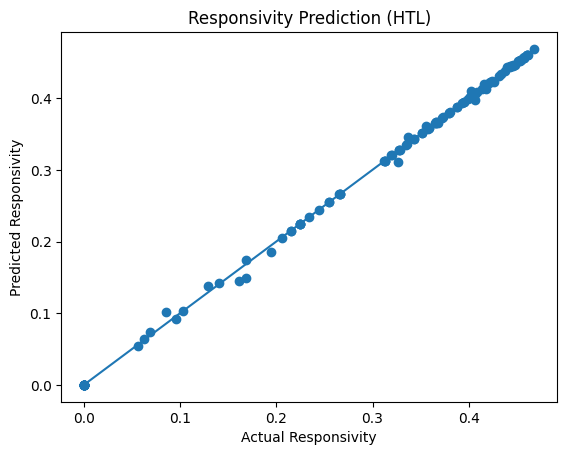

R2: 0.9994106809585889
MAE: 0.001524440294233155


In [57]:
# Predict
y_pred_r = model_r.predict(X_test_r)

# Plot
plt.figure()
plt.scatter(y_test_r, y_pred_r)

# Ideal line
min_val = min(min(y_test_r), min(y_pred_r))
max_val = max(max(y_test_r), max(y_pred_r))

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Responsivity")
plt.ylabel("Predicted Responsivity")
plt.title("Responsivity Prediction (HTL)")
plt.show()

# Metrics
print("R2:", r2_score(y_test_r, y_pred_r))
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))

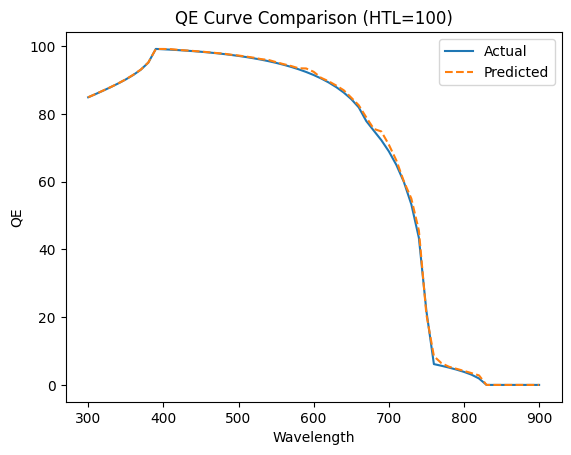

In [58]:
# Select one parameter value
param = qe_long['Parameter'].unique()[0]

# Actual data
actual = qe_long[qe_long['Parameter'] == param]

# Predicted
pred = model_qe.predict(actual[['Wavelength', 'Parameter']])

# Plot
plt.figure()
plt.plot(actual['Wavelength'], actual['QE'], label="Actual")
plt.plot(actual['Wavelength'], pred, linestyle='--', label="Predicted")

plt.xlabel("Wavelength")
plt.ylabel("QE")
plt.title(f"QE Curve Comparison (HTL={param})")
plt.legend()
plt.show()

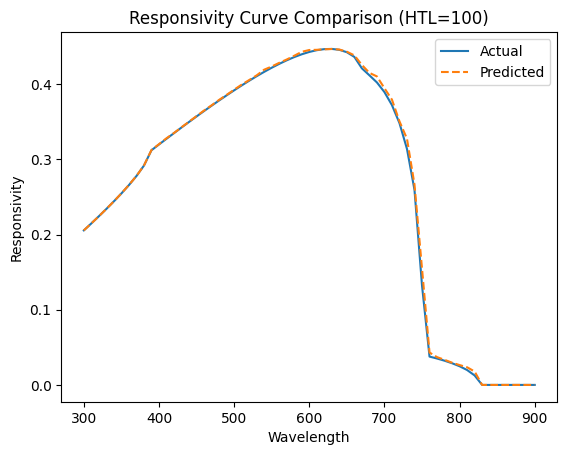

In [59]:
param = r_long['Parameter'].unique()[0]

actual = r_long[r_long['Parameter'] == param]

pred = model_r.predict(actual[['Wavelength', 'Parameter']])

plt.figure()
plt.plot(actual['Wavelength'], actual['Responsivity'], label="Actual")
plt.plot(actual['Wavelength'], pred, linestyle='--', label="Predicted")

plt.xlabel("Wavelength")
plt.ylabel("Responsivity")
plt.title(f"Responsivity Curve Comparison (HTL={param})")
plt.legend()
plt.show()

In [54]:
def predict_jv_curve(parameter):
    voltages = np.linspace(jv_long['Voltage'].min(), jv_long['Voltage'].max(), 100)
    preds = model_jv.predict(np.column_stack([voltages, [parameter]*100]))
    
    plt.figure()
    plt.plot(voltages, preds)
    plt.xlabel("Voltage")
    plt.ylabel("Current")
    plt.title(f"Predicted J–V Curve (HTL={parameter})")
    plt.show()

In [61]:
def predict_qe_curve(parameter):
    wavelengths = np.linspace(qe_long['Wavelength'].min(), qe_long['Wavelength'].max(), 100)
    preds = model_qe.predict(np.column_stack([wavelengths, [parameter]*100]))
    
    plt.figure()
    plt.plot(wavelengths, preds)
    plt.xlabel("Wavelength")
    plt.ylabel("QE")
    plt.title(f"Predicted QE Curve (HTL={parameter})")
    plt.show()

In [60]:
def predict_responsivity_curve(parameter):
    wavelengths = np.linspace(r_long['Wavelength'].min(), r_long['Wavelength'].max(), 100)
    preds = model_r.predict(np.column_stack([wavelengths, [parameter]*100]))
    
    plt.figure()
    plt.plot(wavelengths, preds)
    plt.xlabel("Wavelength")
    plt.ylabel("Responsivity")
    plt.title(f"Predicted Responsivity Curve (HTL={parameter})")
    plt.show()

In [69]:
param = float(input("Enter HTL thickness value: "))

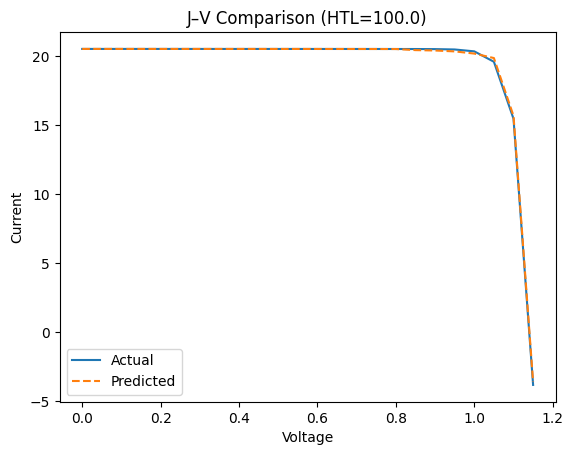

In [66]:
jv_actual = jv_long[jv_long['Parameter'] == param]

if len(jv_actual) > 0:
    jv_pred = model_jv.predict(jv_actual[['Voltage', 'Parameter']])

    plt.figure()
    plt.plot(jv_actual['Voltage'], jv_actual['Current'], label="Actual")
    plt.plot(jv_actual['Voltage'], jv_pred, linestyle='--', label="Predicted")

    plt.xlabel("Voltage")
    plt.ylabel("Current")
    plt.title(f"J–V Comparison (HTL={param})")
    plt.legend()
    plt.show()
else:
    print(f"No actual J–V data found for HTL={param}")

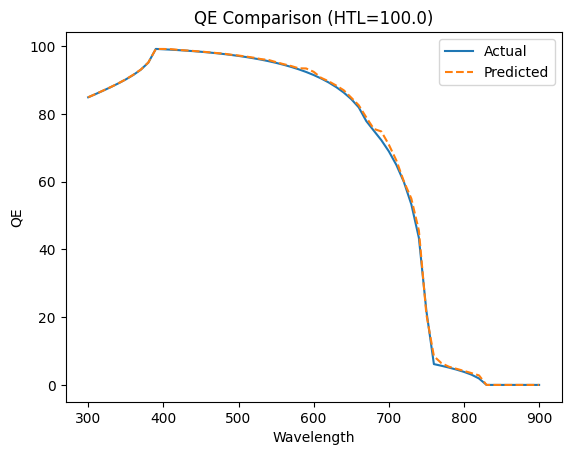

In [67]:
qe_actual = qe_long[qe_long['Parameter'] == param]

if len(qe_actual) > 0:
    qe_pred = model_qe.predict(qe_actual[['Wavelength', 'Parameter']])

    plt.figure()
    plt.plot(qe_actual['Wavelength'], qe_actual['QE'], label="Actual")
    plt.plot(qe_actual['Wavelength'], qe_pred, linestyle='--', label="Predicted")

    plt.xlabel("Wavelength")
    plt.ylabel("QE")
    plt.title(f"QE Comparison (HTL={param})")
    plt.legend()
    plt.show()
else:
    print(f"No actual QE data found for HTL={param}")

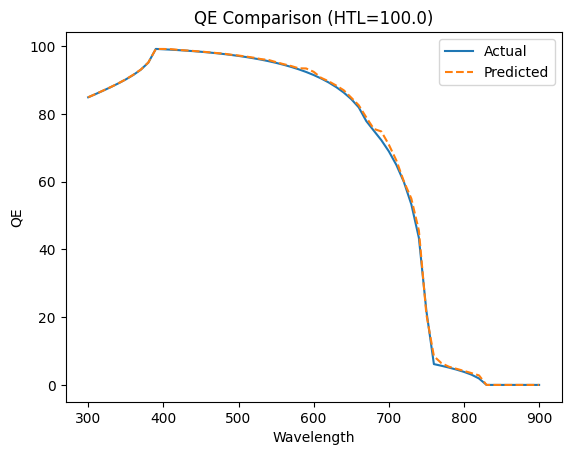

In [68]:
qe_actual = qe_long[qe_long['Parameter'] == param]

if len(qe_actual) > 0:
    qe_pred = model_qe.predict(qe_actual[['Wavelength', 'Parameter']])

    plt.figure()
    plt.plot(qe_actual['Wavelength'], qe_actual['QE'], label="Actual")
    plt.plot(qe_actual['Wavelength'], qe_pred, linestyle='--', label="Predicted")

    plt.xlabel("Wavelength")
    plt.ylabel("QE")
    plt.title(f"QE Comparison (HTL={param})")
    plt.legend()
    plt.show()
else:
    print(f"No actual QE data found for HTL={param}")

In [ ]:
param = float(input("Enter HTL thickness: "))
voltage = float(input("Enter Voltage: "))

prediction = model_jv.predict([[voltage, param]])[0]

print(f"Predicted Current Density = {prediction}")

In [70]:
param = float(input("Enter HTL thickness: "))
wavelength = float(input("Enter Wavelength: "))

prediction = model_qe.predict([[wavelength, param]])[0]

print(f"Predicted QE = {prediction}")

Predicted QE = 87.9380862000001


/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [71]:
param = float(input("Enter HTL thickness: "))
wavelength = float(input("Enter Wavelength: "))

prediction = model_r.predict([[wavelength, param]])[0]

print(f"Predicted Responsivity = {prediction}")

Predicted Responsivity = 0.20553649911290292


/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# HTL (Hole Transport Layer) extracts photogenerated holes from the perovskite absorber 
# and transports them to the electrode while blocking electrons to reduce recombination.
# It acts as a selective contact, improving charge separation and device performance.
# Proper energy band alignment ensures efficient hole transfer and enhances Voc and efficiency.
# HTL performance depends on properties like high hole mobility, low defect density, and doping.
# Low defects reduce recombination, while optimal doping improves carrier transport.
# HTL thickness (~50 nm) must be optimized to balance efficient transport and low resistance.